# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
a = pd.read_csv('finalochka_dataseta_merg.csv')

In [3]:
a.isnull().sum()

,0
ticker,0
published_at,0
date_trading,0
title,0
text,994
category,0
url,0
sentiment_positive,994
sentiment_negative,994
sentiment_neutral,994


In [4]:
a.isnull().mean() * 100 #propotion to the total

,0
ticker,0.000000
published_at,0.000000
date_trading,0.000000
title,0.000000
text,10.754084
category,0.000000
url,0.000000
sentiment_positive,10.754084
sentiment_negative,10.754084
sentiment_neutral,10.754084


Firslty  we need to understand why we have gaps in the Text column. Their share is slightly more than 10% and we assume that it won't be too critical if we delete them. These columns should contain information for further analysis, without which these rows are not needed

So we will delete the lines anyway, but we need to understand the reason for these NaNs

Let's display the lines with gaps on the screen

In [5]:
a[a.isna().any(axis=1)]

,ticker,published_at,date_trading,title,text,category,url,sentiment_positive,sentiment_negative,sentiment_neutral,current_price,price_next,target,is_dividend_day,in_imoex,volume
2,MTSS,2025-04-08 07:01:07,2025-04-08,Краха не избежать. Почему массовые увольнения ...,NaN,Не определена,https://pro.rbc.ru/demo/67ee2b879a79474dd13bb3db,NaN,NaN,NaN,202.10,216.05,6.902524,0,1,3935630.0
7,MTSS,2025-11-25 10:20:42,2025-11-25,Agile устарел: чем его можно заменить,NaN,Не определена,https://pro.rbc.ru/demo/692043c39a7947e8f6c444d3,NaN,NaN,NaN,211.55,212.20,0.307256,0,1,2826190.0
28,MTSS,2025-12-10 07:30:51,2025-12-10,Gucci и Miu Miu из портовых запасов: какой люк...,NaN,Не определена,https://pro.rbc.ru/demo/6936de359a79476f9833dca8,NaN,NaN,NaN,214.05,215.70,0.770848,0,1,1924150.0
32,MTSS,2025-08-26 08:04:47,2025-08-26,Как шантажируют порнодипфейками и актуальна ли...,NaN,Не определена,https://pro.rbc.ru/demo/689f5e249a7947031623d006,NaN,NaN,NaN,224.00,224.00,0.000000,0,1,2505100.0
58,MTSS,2025-10-24 04:27:07,2025-10-24,Ударят ли новые санкции против банков по плате...,NaN,Не определена,https://pro.rbc.ru/demo/68fa15659a7947bb46654875,NaN,NaN,NaN,200.65,199.00,-0.822327,0,1,2764820.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9169,VTBR,2025-09-22 00:00:10,2025-09-22,Почему платежи за рубеж так подешевели и что с...,NaN,Не определена,https://pro.rbc.ru/demo/68cd51c09a7947145b25f893,NaN,NaN,NaN,70.94,70.25,-0.972653,0,1,138252439.0
9183,VTBR,2025-10-08 00:06:28,2025-10-08,"В Конституционном суде обсудили, кто должен оп...",NaN,Не определена,https://pro.rbc.ru/demo/68e4d6c79a7947d440ace6ab,NaN,NaN,NaN,66.04,67.80,2.665051,0,1,165720130.0
9205,VTBR,2025-10-17 07:30:00,2025-10-17,16% или пауза. Все сценарии ЦБ по ставке и их ...,NaN,Не определена,https://pro.rbc.ru/demo/68f0f1fb9a7947193726cde5,NaN,NaN,NaN,70.38,71.42,1.477693,0,1,117563236.0
9218,VTBR,2025-10-17 15:26:45,2025-10-17,«Хрупкий фактор»: изменят ли переговоры России...,NaN,Не определена,https://pro.rbc.ru/demo/68f1e6f49a7947661860d9af,NaN,NaN,NaN,70.38,71.42,1.477693,0,1,117563236.0


It's possible that we can't just scrap a certain subdomain of RBC. Let's take a closer look

In [6]:
a[a.isna().any(axis=1)]['url']

,url
2,https://pro.rbc.ru/demo/67ee2b879a79474dd13bb3db
7,https://pro.rbc.ru/demo/692043c39a7947e8f6c444d3
28,https://pro.rbc.ru/demo/6936de359a79476f9833dca8
32,https://pro.rbc.ru/demo/689f5e249a7947031623d006
58,https://pro.rbc.ru/demo/68fa15659a7947bb46654875
...,...
9169,https://pro.rbc.ru/demo/68cd51c09a7947145b25f893
9183,https://pro.rbc.ru/demo/68e4d6c79a7947d440ace6ab
9205,https://pro.rbc.ru/demo/68f0f1fb9a7947193726cde5
9218,https://pro.rbc.ru/demo/68f1e6f49a7947661860d9af


Here we will need to remember smth about regular expressions to create a separate column with a subdomain. Where is our super puper cheatsheet?????

In [7]:
a['domain'] = a['url'].str.extract(r'https?://(?:www\.)?([^/]+)')

In [8]:
a[a.isna().any(axis=1)]['domain'].value_counts()

,count
domain,
pro.rbc.ru,974
rbc.ru,19
trends.rbc.ru,1


We see that most of the passes are in our subdomain. pro.rbc.ru

Our hypothesis: these gaps are not accidental, but are a connected with  the architecture of the RBC website.

In [9]:
a[a.isna().any(axis=1)]

,ticker,published_at,date_trading,title,text,category,url,sentiment_positive,sentiment_negative,sentiment_neutral,current_price,price_next,target,is_dividend_day,in_imoex,volume,domain
2,MTSS,2025-04-08 07:01:07,2025-04-08,Краха не избежать. Почему массовые увольнения ...,NaN,Не определена,https://pro.rbc.ru/demo/67ee2b879a79474dd13bb3db,NaN,NaN,NaN,202.10,216.05,6.902524,0,1,3935630.0,pro.rbc.ru
7,MTSS,2025-11-25 10:20:42,2025-11-25,Agile устарел: чем его можно заменить,NaN,Не определена,https://pro.rbc.ru/demo/692043c39a7947e8f6c444d3,NaN,NaN,NaN,211.55,212.20,0.307256,0,1,2826190.0,pro.rbc.ru
28,MTSS,2025-12-10 07:30:51,2025-12-10,Gucci и Miu Miu из портовых запасов: какой люк...,NaN,Не определена,https://pro.rbc.ru/demo/6936de359a79476f9833dca8,NaN,NaN,NaN,214.05,215.70,0.770848,0,1,1924150.0,pro.rbc.ru
32,MTSS,2025-08-26 08:04:47,2025-08-26,Как шантажируют порнодипфейками и актуальна ли...,NaN,Не определена,https://pro.rbc.ru/demo/689f5e249a7947031623d006,NaN,NaN,NaN,224.00,224.00,0.000000,0,1,2505100.0,pro.rbc.ru
58,MTSS,2025-10-24 04:27:07,2025-10-24,Ударят ли новые санкции против банков по плате...,NaN,Не определена,https://pro.rbc.ru/demo/68fa15659a7947bb46654875,NaN,NaN,NaN,200.65,199.00,-0.822327,0,1,2764820.0,pro.rbc.ru
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9169,VTBR,2025-09-22 00:00:10,2025-09-22,Почему платежи за рубеж так подешевели и что с...,NaN,Не определена,https://pro.rbc.ru/demo/68cd51c09a7947145b25f893,NaN,NaN,NaN,70.94,70.25,-0.972653,0,1,138252439.0,pro.rbc.ru
9183,VTBR,2025-10-08 00:06:28,2025-10-08,"В Конституционном суде обсудили, кто должен оп...",NaN,Не определена,https://pro.rbc.ru/demo/68e4d6c79a7947d440ace6ab,NaN,NaN,NaN,66.04,67.80,2.665051,0,1,165720130.0,pro.rbc.ru
9205,VTBR,2025-10-17 07:30:00,2025-10-17,16% или пауза. Все сценарии ЦБ по ставке и их ...,NaN,Не определена,https://pro.rbc.ru/demo/68f0f1fb9a7947193726cde5,NaN,NaN,NaN,70.38,71.42,1.477693,0,1,117563236.0,pro.rbc.ru
9218,VTBR,2025-10-17 15:26:45,2025-10-17,«Хрупкий фактор»: изменят ли переговоры России...,NaN,Не определена,https://pro.rbc.ru/demo/68f1e6f49a7947661860d9af,NaN,NaN,NaN,70.38,71.42,1.477693,0,1,117563236.0,pro.rbc.ru


By opening one of the links and analysing the article, we can confirm our hypothesis about subdomain pro.rbc.ru It is an RBC Pro platform section with paid subscription access. When collecting data the parser successfully coped and received the public metadata of the articles, but it was not possible to get the text of the article, since access to it is paid. And the parser just doesn't see the full text. Moreover, copying the shown text of the article does not work. That is why there are 974 gaps in our dataset in the column with text and tonality analysis, respectively

In [10]:
a.isnull().sum()

,0
ticker,0
published_at,0
date_trading,0
title,0
text,994
category,0
url,0
sentiment_positive,994
sentiment_negative,994
sentiment_neutral,994


In [11]:
s = a.isnull().sum().sum()
s

np.int64(3976)

In [12]:
sp = s / a.size
sp #spars the relation of zero to all

np.float64(0.025303727463072214)

In [13]:
f = a.dropna()

In [14]:
f.isnull().sum()

,0
ticker,0
published_at,0
date_trading,0
title,0
text,0
category,0
url,0
sentiment_positive,0
sentiment_negative,0
sentiment_neutral,0


1. (994 * 4) rows with missing values
2. text	10.754084%
sentiment_positive 10.754084%
sentiment_negative 10.754084%
sentiment_neutral	10.754084%

3. the ratio of gaps to all lines 0.02867755779148184
(2.9%)
4. we deleted the empty values simply through dropna

## Error value analysis

Now our task is to see if there are any error values in the data

In [15]:
f.describe()

,sentiment_positive,sentiment_negative,sentiment_neutral,current_price,price_next,target,is_dividend_day,in_imoex,volume
count,8249.000000,8249.000000,8249.000000,8249.000000,8249.000000,8249.000000,8249.000000,8249.0,8.249000e+03
mean,0.156380,0.165173,0.678447,1628.169624,1626.411679,-0.042016,0.004607,1.0,1.934708e+07
std,0.166229,0.177849,0.262472,2538.565112,2535.680937,2.070255,0.067720,0.0,3.379505e+07
min,0.017000,0.006900,0.006900,38.380000,38.350000,-36.308834,0.000000,1.0,1.890900e+04
25%,0.062300,0.061900,0.584300,126.700000,127.020000,-0.938967,0.000000,1.0,7.010040e+05
50%,0.106600,0.106300,0.780800,253.080000,251.900000,-0.015803,0.000000,1.0,4.249218e+06
75%,0.180200,0.182900,0.874900,2851.000000,2851.000000,0.829840,0.000000,1.0,2.359659e+07
max,0.986200,0.951900,0.966100,8444.000000,8444.000000,17.167488,1.000000,1.0,4.527762e+08


In [16]:
f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8249 entries, 0 to 9242
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ticker              8249 non-null   object 
 1   published_at        8249 non-null   object 
 2   date_trading        8249 non-null   object 
 3   title               8249 non-null   object 
 4   text                8249 non-null   object 
 5   category            8249 non-null   object 
 6   url                 8249 non-null   object 
 7   sentiment_positive  8249 non-null   float64
 8   sentiment_negative  8249 non-null   float64
 9   sentiment_neutral   8249 non-null   float64
 10  current_price       8249 non-null   float64
 11  price_next          8249 non-null   float64
 12  target              8249 non-null   float64
 13  is_dividend_day     8249 non-null   int64  
 14  in_imoex            8249 non-null   int64  
 15  volume              8249 non-null   float64
 16  domain     

In [17]:
f.ticker.unique()

array(['MTSS', 'GMKN', 'SBER', 'MGNT', 'LKOH', 'GAZP', 'ROSN', 'ALRS',
       'VTBR'], dtype=object)

There is no extra data in the ticker column. only our necessary tickers

Now let's look at the sensetivity analysis and see if there are lines where the sum of all three indicators is less than or greater than 1

In [18]:
summ = f[['sentiment_positive', 'sentiment_negative', 'sentiment_neutral']].sum(axis=1)
f[(summ < 0.99)|(summ > 1.01)]

,ticker,published_at,date_trading,title,text,category,url,sentiment_positive,sentiment_negative,sentiment_neutral,current_price,price_next,target,is_dividend_day,in_imoex,volume,domain


We have no problems with the analysis of sentiments

In [19]:
f.in_imoex.unique()

array([1])

 The in_imoex column contains only 1, everything is fine, there are no problems with this, but the column can be deleted, since it does not carry any further  analyzis.

In [20]:
f = f.drop(columns=['in_imoex'])

In [21]:
f.category.value_counts()

,count
category,
Не определена,4440
Новости,1258
События дня,397
Пресс-релизы,298
РБК Банки,160
...,...
"Дивиденды: кто, сколько и когда заплатит",1
Калининградские офшоры,1
TNF 2025,1


In [22]:
f.category.unique()


array(['Тенденции', 'Не определена', 'Новости', 'Инструкции',
       'Криптовалюта', 'Экспертиза', 'Инновации', 'Новости партнеров',
       'Компетенция', 'События дня', 'Инвестидеи', 'РБК Банки',
       'Пресс-релизы', 'Практика', 'Академия', 'Что это значит',
       'Конференция РБК-Крипто', 'События недели', 'Итоги месяца',
       'От первого лица', 'IPO', 'Мнение профи', 'Инструменты', 'Решение',
       'Деньги', 'Другие', 'Решения', 'Интервью', 'Майнинг', 'ЦФА',
       'Хоккей', 'Подборки', 'Баскетбол', 'Цифровой рубль', 'Кризис',
       'Личный опыт', 'Истории компаний', 'Рыночный расклад', 'Биржи',
       'Эирдроп', 'Стратегия', 'Дайджесты', 'Считаем дивиденды',
       'Акции на хайпе', 'Биржевые истории', 'Курсы валют', 'Блокчейн',
       'Календарь инвестора', 'Футбол', 'Регулирование', 'Жилье',
       'Новости компаний', 'Загород', 'Отрасль', 'Статья', 'Новость',
       'Город', 'Ваш дом', 'Дизайн', 'Бизнес-кейс',
       'Продажа российского «Яндекса»', 'Бизнес', 'Ростов-на-Д

 That is s where the problem is, the categories are too vague, and we need more specifics. For example, there are Sports and Football categories so they can be combined. The Russian regions can also be united. It needs to be cleaned here

In [23]:
obiedinen_categor = {
    'Тенденции':'Инвестиции',
    'Инвестидеи':'Инвестиции',
    'Акции на хайпе':'Инвестиции',
    'Считаем дивиденды':'Инвестиции',
    'Рыночный расклад':'Инвестиции',
    'Биржевые истории': 'Инвестиции',
    'Биржи': 'Инвестиции',
    'Календарь инвестора': 'Инвестиции',
    'Курсы валют': 'Инвестиции',
    'Обзор валют': 'Инвестиции',
    'IPO': 'Инвестиции',
    'Стратегия': 'Инвестиции',
    'Дивиденды: кто, сколько и когда заплатит': 'Инвестиции',
    'Курс рубля: текущие котировки, динамика и прогнозы': 'Инвестиции',
    'Новости': 'Новости',
    'Новости компаний': 'Новости',
    'Новости партнеров': 'Новости',
'События дня': 'Новости',
    'События недели': 'Новости',
    'Итоги месяца': 'Новости',
    'Дайджесты': 'Новости',
    'Пресс-релизы': 'Новости',
 'Статья': 'Новости',
 'Новость': 'Новости',
 'Отрасль': 'Новости',
 'Подборки': 'Новости',
 'Экспертиза': 'Аналитика',
 'Мнение профи': 'Аналитика',
 'Мнения': 'Аналитика',
 'От первого лица': 'Аналитика',
 'Интервью': 'Аналитика',
 'Личный опыт': 'Аналитика',
 'Истории компаний': 'Аналитика',
 'Бизнес-кейс': 'Аналитика',
 'Рейтинг РБК 500': 'Аналитика',
 'Эксклюзивы РБК': 'Аналитика',
 'Бизнес': 'Аналитика',
 'Криптовалюта': 'Крипто',
 'Блокчейн': 'Крипто',
 'Майнинг': 'Крипто',
    'ЦФА': 'Крипто',
     'Эирдроп': 'Крипто',
 'Цифровой рубль': 'Крипто',
     'Конференция РБК-Крипто': 'Крипто',
     'Инструкции': 'Обучение',
     'Академия': 'Обучение',
     'Инструменты': 'Обучение',
     'База знаний': 'Обучение',
     'Что это значит': 'Обучение',
     'Практика': 'Обучение',
     'Компетенция': 'Обучение',
     'РБК Образование': 'Обучение',
     'Экономика': 'Макро',
     'Финансы': 'Макро',
     'Политика': 'Макро',
     'Регулирование': 'Макро',
     'Кризис': 'Макро',
     'Война санкций': 'Макро',
     'Налоги для юридических лиц': 'Макро',
     'Переговоры России и США': 'Макро',
     'Возвращение Трампа в Белый дом': 'Макро',
     'Военная операция на Украине': 'Макро',
     'Обострение между Москвой и Баку': 'Макро',
     'Продажа российского «Яндекса»': 'Макро',
     'Технологии и медиа': 'Макро',
     'Инновации': 'Макро',
     'Общество': 'Макро',
     'Хоккей': 'Спорт',
     'Баскетбол': 'Спорт',
     'Футбол': 'Спорт',
     'Спорт': 'Спорт',
     'Жилье': 'Жильё',
     'Загород': 'Жильё',
     'Недвижимость Тюмени': 'Жильё',
     'Ваш дом': 'Жильё',
     'Авторынок': 'Авто',
     'Дороги': 'Авто',
     'Ростов-на-Дону': 'Регионы',
     'Санкт-Петербург и область': 'Регионы',
     'Пермь': 'Регионы',
     'Башкортостан': 'Регионы',
     'Калининград': 'Регионы',
     'Краснодар': 'Регионы',
     'Н.Новгород': 'Регионы',
     'Татарстан': 'Регионы',
     'Кавказ': 'Регионы',
     'Вологда': 'Регионы',
     'Мурманск': 'Регионы',
     'Карелия': 'Регионы',
     'Омск': 'Регионы',
     'Новосибирск': 'Регионы',
     'Тюмень': 'Регионы',
     'Приморье': 'Регионы',
     'TNF 2023': 'Спецпроекты',
     'TNF 2025': 'Спецпроекты',
     'ПМЭФ-2025': 'Спецпроекты',
     'ПМЭФ: Сила Юга': 'Спецпроекты',
     'PROюгАгро': 'Спецпроекты',
     'ProКадры': 'Спецпроекты',
     'ОЭЗ в Калининграде': 'Спецпроекты',
     'Калининградские офшоры': 'Спецпроекты',
     'Финансы Тюменского региона': 'Спецпроекты',
     'Дело сенатора Савельева': 'Спецпроекты',
     'Радио РБК': 'Спецпроекты',
     'РБК Банки': 'Спецпроекты',
     'Город': 'Прочее',
     'Дизайн': 'Прочее',
     'Деньги': 'Прочее',
     'Решение': 'Прочее',
     'Решения': 'Прочее',
     'Не определена': 'Прочее',
     'Другие': 'Прочее',
     'Как защититься от мошенников': 'Прочее',
     'Обострение между Москвой и Баку': 'Прочее'
}

In [24]:
f['category'] = f['category'].map(obiedinen_categor)

In [25]:
f.isna().sum()

,0
ticker,0
published_at,0
date_trading,0
title,0
text,0
category,0
url,0
sentiment_positive,0
sentiment_negative,0
sentiment_neutral,0


In [26]:
f.category.unique()

array(['Инвестиции', 'Прочее', 'Новости', 'Обучение', 'Крипто',
       'Аналитика', 'Макро', 'Спецпроекты', 'Спорт', 'Жильё', 'Регионы',
       'Авто'], dtype=object)

In [27]:
f.category.value_counts()

,count
category,
Прочее,4540
Новости,2160
Обучение,358
Макро,285
Регионы,218
Аналитика,217
Спецпроекты,196
Инвестиции,147
Спорт,80


Categories are now updated, noise has now been removed and articles are broken down more specifically

Let's check if we have prices less than or equal to zero

In [28]:
(f[['current_price', 'price_next']] <= 0).sum()

,0
current_price,0
price_next,0


Now let's look at our  target

In [29]:
f['target'].describe()

,target
count,8249.000000
mean,-0.042016
std,2.070255
min,-36.308834
25%,-0.938967
50%,-0.015803
75%,0.829840
max,17.167488


The average price practically does not change. Let's see the biggest price changes in one day

In [30]:
f.nsmallest(5, 'target')

,ticker,published_at,date_trading,title,text,category,url,sentiment_positive,sentiment_negative,sentiment_neutral,current_price,price_next,target,is_dividend_day,volume,domain
7008,ROSN,2022-02-22 15:11:21,2022-02-22,"«Роснефть» будет добывать газ, несмотря на воз...",«Роснефть» планирует заниматься разработкой но...,Новости,https://www.rbc.ru/quote/news/short_article/62...,0.0509,0.0509,0.8982,431.3,274.7,-36.308834,0,79552638.0,rbc.ru
7353,ROSN,2022-02-22 21:52:45,2022-02-22,Статус российских акций: осторожный оптимизм и...,Основная сессия на российском фондовом рынке в...,Прочее,https://www.rbc.ru/finances/22/02/2022/6215205...,0.1774,0.1774,0.6451,431.3,274.7,-36.308834,0,79552638.0,rbc.ru
1399,GMKN,2022-02-22 12:57:49,2022-02-22,Статус российских акций: сырье восстанавливает...,Падение российского фондового рынка продолжает...,Прочее,https://www.rbc.ru/finances/22/02/2022/6214a16...,0.1482,0.1482,0.7035,211.5,182.0,-13.947991,0,1127953.0,rbc.ru
1687,GMKN,2022-02-22 17:50:24,2022-02-22,Новосибирские эксперты о последствиях кризиса ...,А РБК Новосибирск провел опрос на тему рисков ...,Прочее,https://nsk.rbc.ru/nsk/22/02/2022/6214ecf29a79...,0.0973,0.0973,0.8054,211.5,182.0,-13.947991,0,1127953.0,nsk.rbc.ru
6281,ROSN,2022-09-23 09:20:12,2022-09-23,"Референдумы, индекс Мосбиржи, санкции ЕС и пот...","С 23 по 27 сентября в республиках Донбасса, а ...",Новости,https://www.rbc.ru/quote/news/article/632c6353...,0.0241,0.0241,0.9518,296.7,257.9,-13.077182,0,8332681.0,rbc.ru


4 из 5 строки связаны с событиями произошедшими 22 февраля 2022 года. Этим можно объяснить резкое падение стоимости акций

In [31]:
f.nlargest(5, 'target')

,ticker,published_at,date_trading,title,text,category,url,sentiment_positive,sentiment_negative,sentiment_neutral,current_price,price_next,target,is_dividend_day,volume,domain
1635,GMKN,2020-03-23 14:54:35,2020-03-23,Потанин объявил о выделении ₽1 млрд на поддерж...,На поддержку некоммерческого сектора миллиарде...,Прочее,https://www.rbc.ru/society/23/03/2020/5e789ce1...,0.0912,0.0912,0.8176,162.40,190.28,17.167488,0,450423.0,rbc.ru
6474,ROSN,2022-02-25 18:48:14,2022-02-25,Статус российских акций: неравномерное восстан...,Послетяжелейшегообвала в истории российского ф...,Прочее,https://www.rbc.ru/finances/25/02/2022/6218c46...,0.0864,0.0864,0.8273,307.95,360.20,16.967040,0,34248855.0,rbc.ru
6750,ROSN,2022-02-25 09:18:25,2022-02-25,"Отмена утренних торгов, укрепление рубля, санк...",Мосбиржа25 февраля отменила утренние торговые ...,Новости,https://www.rbc.ru/quote/news/article/62185643...,0.1313,0.7373,0.1313,307.95,360.20,16.967040,0,34248855.0,rbc.ru
7232,ROSN,2022-02-25 03:36:08,2022-02-25,"Беспрецедентные санкции США: банки, госсектор,...",Администрация президента США Джо Байденаобъяви...,Прочее,https://www.rbc.ru/economics/25/02/2022/6217e4...,0.1819,0.1819,0.6361,307.95,360.20,16.967040,0,34248855.0,rbc.ru
7389,ROSN,2022-02-25 16:48:16,2022-02-25,Bloomberg узнал причину нежелания стран ЕС отк...,Предложения об отключении России от международ...,Прочее,https://www.rbc.ru/politics/25/02/2022/6218dc6...,0.1847,0.6306,0.1847,307.95,360.20,16.967040,0,34248855.0,rbc.ru


## Outliers

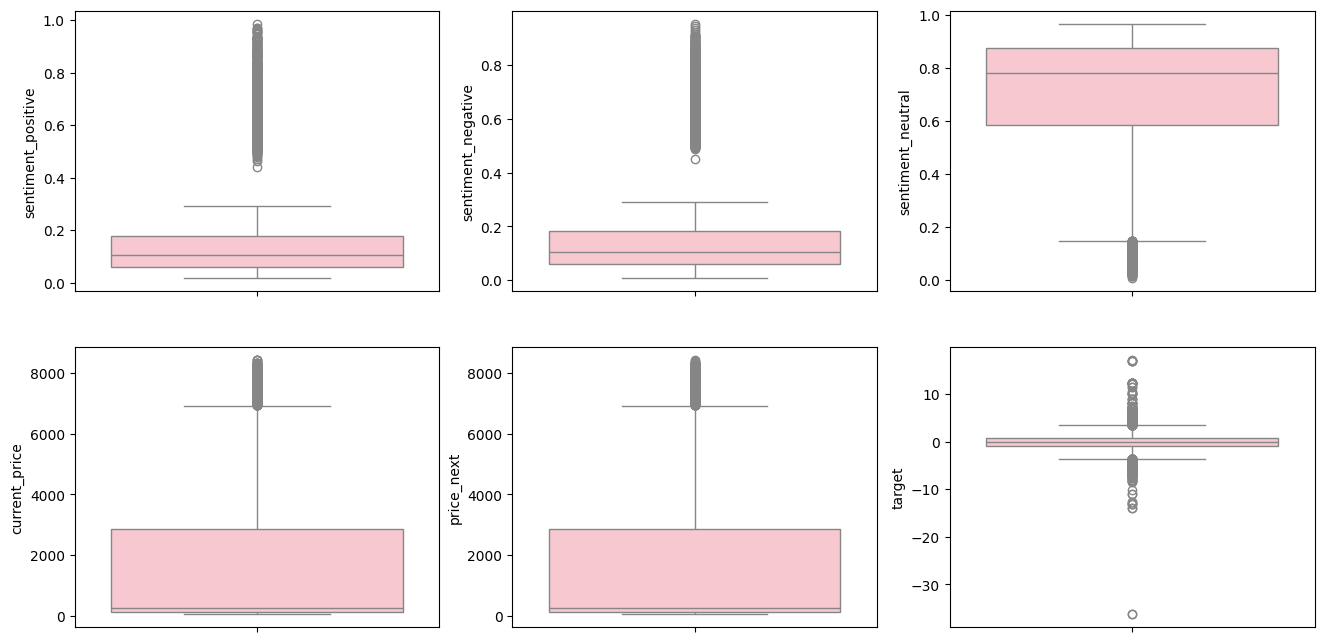

In [32]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 3, 1)
sns.boxplot(y=f['sentiment_positive'], color='pink')
plt.subplot(2, 3, 2)
sns.boxplot(y=f['sentiment_negative'], color='pink')
plt.subplot(2, 3, 3)
sns.boxplot(y=f['sentiment_neutral'], color='pink')
plt.subplot(2, 3, 4)
sns.boxplot(y=f['current_price'], color='pink')
plt.subplot(2, 3, 5)
sns.boxplot(y=f['price_next'], color='pink')
plt.subplot(2, 3, 6)
sns.boxplot(y=f['target'], color='pink')
plt.show()

#### Sentiment_positive and Sentiment_negative

It can be seen a lot of outlier points at the top. These are articles with a strong tone  just real news with a strong emotional tone

#### sentiment_neutral

Here the picture is the opposite. Most of the articles are neutral. The outliers at the bottom are articles with low neutrality, that is, emotional

#### current_price and price_next

There are no outliers, it's just that each stock costs differently, some cheaper, some more expensive

#### target

the median is about 0, we have already processed the single points earlier, they are related to the events of February 22, 2022

Thus, there are no outliers in our dataset

Next, we look at how the values of each numeric feature are distributed

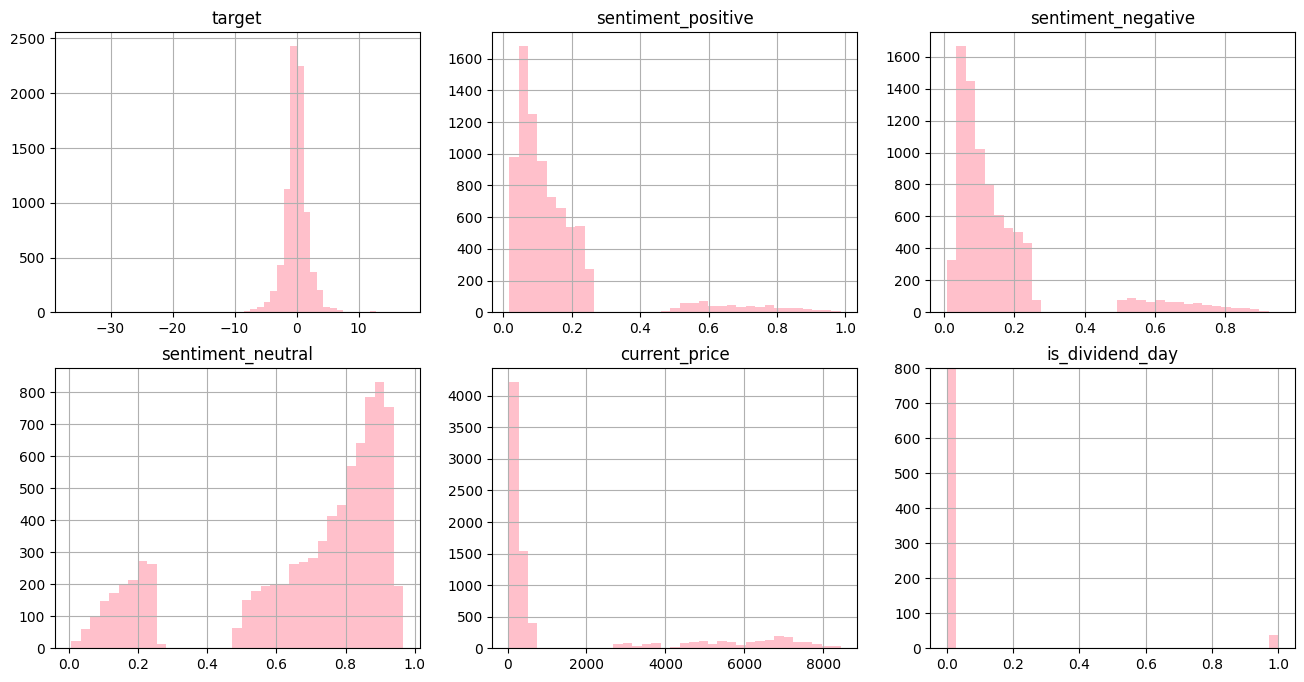

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
f['target'].hist(bins=50, ax=axes[0][0], color='pink')
axes[0][0].set_title('target')
f['sentiment_positive'].hist(bins=35, ax=axes[0][1], color='pink')
axes[0][1].set_title('sentiment_positive')
f['sentiment_negative'].hist(bins=35, ax=axes[0][2], color='pink')
axes[0][2].set_title('sentiment_negative')
f['sentiment_neutral'].hist(bins=35, ax=axes[1][0], color='pink')
axes[1][0].set_title('sentiment_neutral')
f['current_price'].hist(bins=35, ax=axes[1][1], color='pink')
axes[1][1].set_title('current_price')
f['is_dividend_day'].hist(bins=35, ax=axes[1][2], color='pink')
axes[1][2].set_title('is_dividend_day')

axes[1][2].set_ylim(0, 800) #to better see the dividend days
plt.show()

target - highly concentrated near zero - most days the price hardly moves

sentiment_positive / negative - skewed to the right because most articles have a low level of emotionality

sentiment_neutral - skewed to the left because most of the articles are neutral

current_price - cheap stocks and expensive ones

is_dividend_day - there are very few dividend days compared to the usual ones

Now we are making a correlation matrix to see how the signs are related to each other and our target

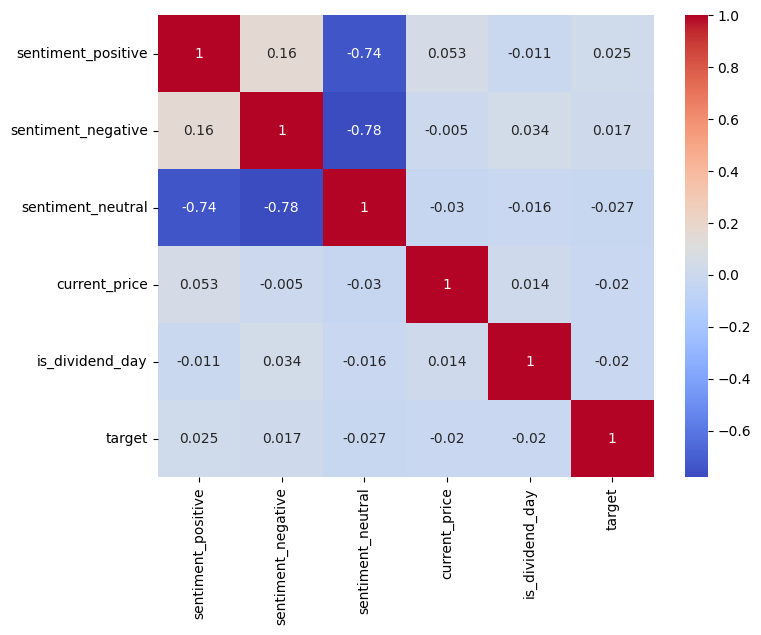

In [34]:
cols = ['sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'current_price', 'is_dividend_day', 'target']
plt.figure(figsize=(8, 6))
sns.heatmap(f[cols].corr(), annot=True, cmap='coolwarm')
plt.show()

The sentiments are strongly related, but that's what we expected, since they add up to 1  
But the correlation of sentiment with target is weak, because the tone of the news does not directly explain the price movement

# Now let's start the ticker analysis

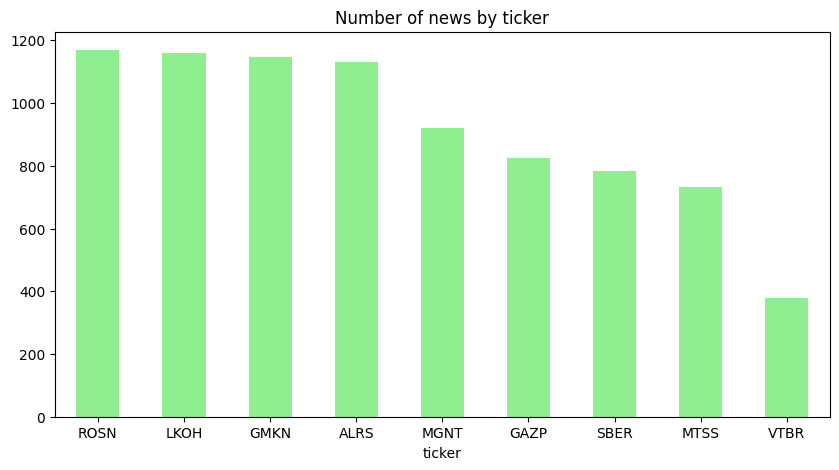

In [35]:
plt.figure(figsize=(10, 5))
f['ticker'].value_counts().plot(kind='bar', color='lightgreen')
plt.xticks(rotation=0)
plt.title('Number of news by ticker')
plt.show()

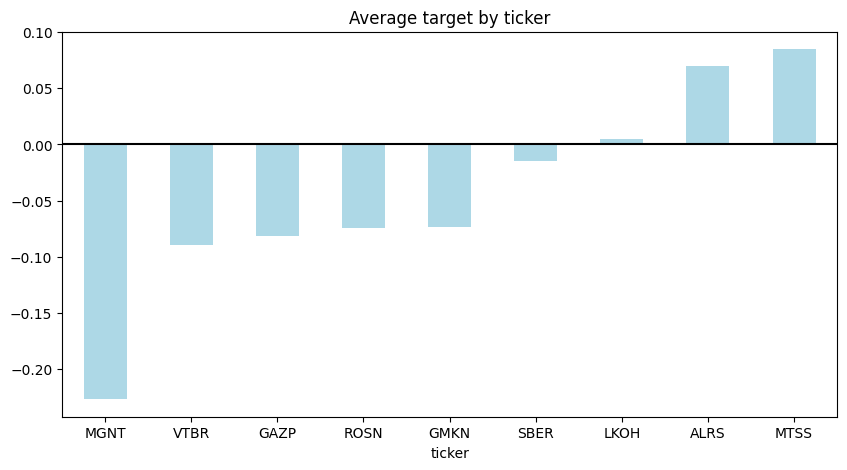

In [36]:
plt.figure(figsize=(10, 5))
f.groupby('ticker')['target'].mean().sort_values().plot(kind='bar', color='lightblue') #если не сортим то смотрится не оч и непонятно как сравнивать маленькие changes в тикерах
plt.title('Average target by ticker')
plt.axhline(0, color='black')
plt.xticks(rotation=0)
plt.show()

In [37]:
f.groupby('ticker')['target'].mean()

,target
ticker,
ALRS,0.070018
GAZP,-0.081684
GMKN,-0.073855
LKOH,0.005240
MGNT,-0.226784
MTSS,0.084793
ROSN,-0.074788
SBER,-0.014382
VTBR,-0.089603


In [38]:
f.groupby('ticker')['target'].median()

,target
ticker,
ALRS,0.029002
GAZP,-0.049482
GMKN,0.013742
LKOH,-0.026709
MGNT,-0.209736
MTSS,0.070671
ROSN,0.070671
SBER,-0.095341
VTBR,-0.101083


In [39]:
f.groupby('ticker')['target'].std()

,target
ticker,
ALRS,2.482230
GAZP,1.872225
GMKN,2.136176
LKOH,1.774254
MGNT,2.086074
MTSS,1.503916
ROSN,2.829462
SBER,1.098017
VTBR,1.256463


In [40]:
f.groupby('ticker')['target'].count()

,target
ticker,
ALRS,1131
GAZP,826
GMKN,1148
LKOH,1161
MGNT,921
MTSS,731
ROSN,1169
SBER,782
VTBR,380


# Analysis by news category

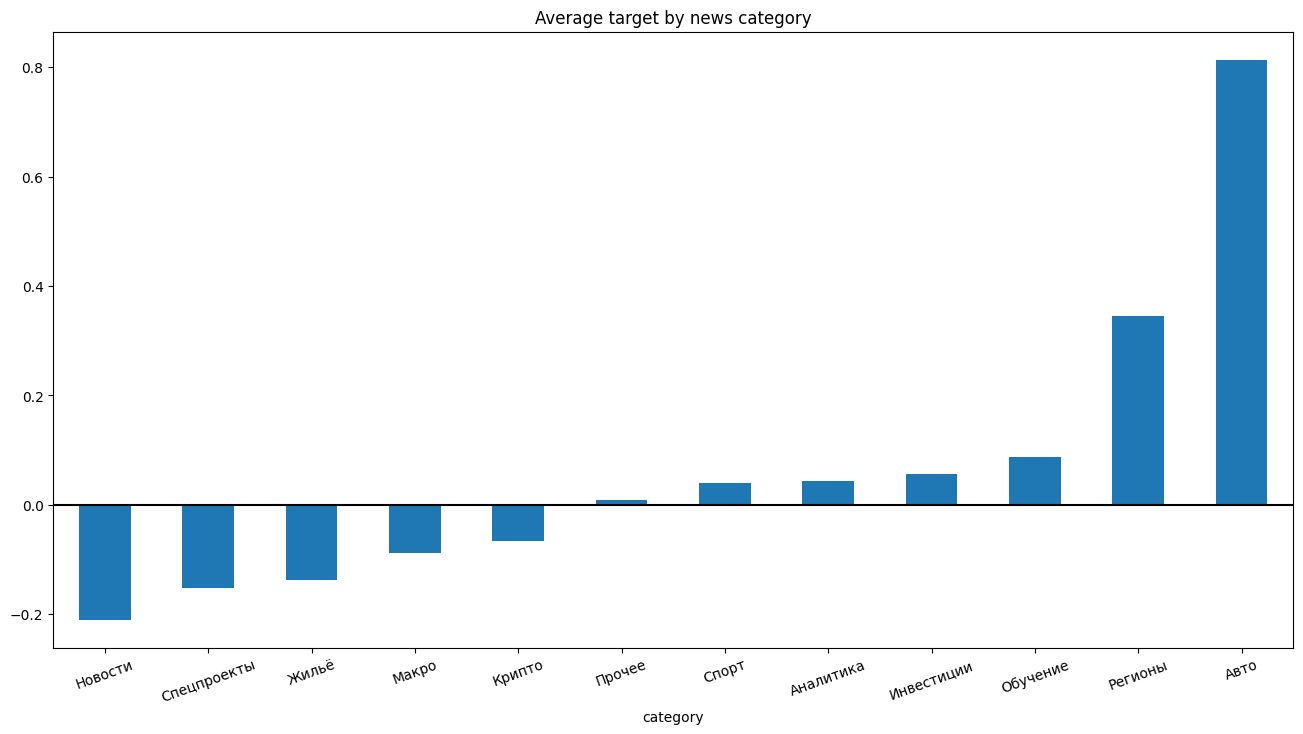

In [41]:
plt.figure(figsize=(16, 8))
f.groupby('category')['target'].mean().sort_values().plot(kind='bar') #сортируем чтобы увидеть разницу с плюс минус одинаковыми категориями
plt.title('Average target by news category')
plt.axhline(0, color='black')
plt.xticks(rotation=20)
plt.show()

In [42]:
f.groupby('category')['target'].mean()

,target
category,
Авто,0.813766
Аналитика,0.042645
Жильё,-0.137206
Инвестиции,0.056219
Крипто,-0.065881
Макро,-0.087567
Новости,-0.210068
Обучение,0.087850
Прочее,0.008307


In [43]:
f.groupby('category')['target'].median()

,target
category,
Авто,0.813766
Аналитика,0.110970
Жильё,-0.049167
Инвестиции,0.074931
Крипто,-0.085348
Макро,-0.100936
Новости,-0.109961
Обучение,0.093755
Прочее,0.000000


In [44]:
f.groupby('category')['target'].std()

,target
category,
Авто,1.499951
Аналитика,1.747779
Жильё,1.803771
Инвестиции,1.836440
Крипто,2.275118
Макро,2.296355
Новости,2.194287
Обучение,1.926166
Прочее,2.073149


In [45]:
f.groupby('category')['target'].count()

,target
category,
Авто,2
Аналитика,217
Жильё,28
Инвестиции,147
Крипто,18
Макро,285
Новости,2160
Обучение,358
Прочее,4540


Now let's check how the dividend days affect the target

In [46]:
f.groupby('is_dividend_day')['target'].mean()

,target
is_dividend_day,
0,-0.039251
1,-0.639536


In [47]:
f.groupby('is_dividend_day')['target'].median()

,target
is_dividend_day,
0,-0.015803
1,-0.110068


In [48]:
f.groupby('is_dividend_day')['target'].std()

,target
is_dividend_day,
0,2.070575
1,1.933755


In [49]:
f.groupby('is_dividend_day')['target'].count()

,target
is_dividend_day,
0,8211
1,38


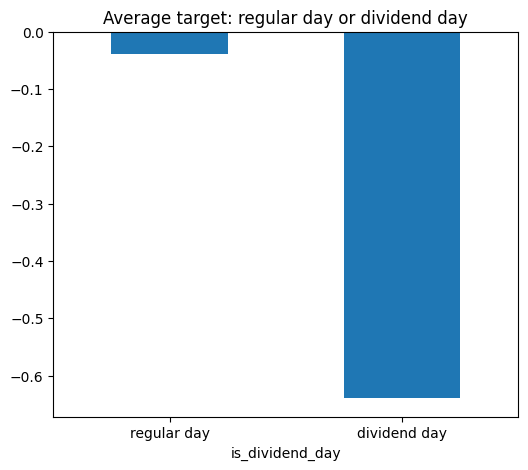

In [50]:
plt.figure(figsize=(6, 5))
f.groupby('is_dividend_day')['target'].mean().plot(kind='bar')
plt.title('Average target: regular day or dividend day')
plt.xticks([0, 1], ['regular day', 'dividend day'], rotation=0)
plt.show()

# Text column analysis

In [51]:
f.head()

,ticker,published_at,date_trading,title,text,category,url,sentiment_positive,sentiment_negative,sentiment_neutral,current_price,price_next,target,is_dividend_day,volume,domain
0,MTSS,2025-06-17 16:16:19,2025-06-17,Структурная перезагрузка,В географически и логистически оторванном от к...,Инвестиции,https://spb.plus.rbc.ru/news/685023957a8aa93a0...,0.0798,0.0798,0.8404,226.05,228.45,1.061712,0,2507580.0,spb.plus.rbc.ru
1,MTSS,2025-03-07 11:06:23,2025-03-07,"Каждый четвертый мужчина уверен, что не поздра...","SuperJob: каждый четвертый мужчина уверен, что...",Прочее,https://www.rbc.ru/life/news/67cacfbd9a79472db...,0.1506,0.1506,0.6988,242.00,239.75,-0.929752,0,2523570.0,rbc.ru
3,MTSS,2025-03-08 09:00:22,2025-03-10,Брокеры составили портрет среднестатистической...,Российские женщины-инвесторы оказались успешне...,Новости,https://www.rbc.ru/quote/news/article/67cad261...,0.1065,0.1065,0.7871,239.75,240.80,0.437956,0,1610170.0,rbc.ru
4,MTSS,2025-07-25 16:05:18,2025-07-25,В торговых центрах Петербурга стали закрыватьс...,В первом полугодии 2025 года в торговых центра...,Прочее,https://www.rbc.ru/spb_sz/25/07/2025/68837e709...,0.0832,0.0832,0.8336,209.35,209.70,0.167184,0,3503960.0,rbc.ru
5,MTSS,2025-05-06 11:03:57,2025-05-06,МТС назначила нового директора филиала в Ставр...,Директором филиала МТС в Ставропольском крае н...,Прочее,https://kavkaz.rbc.ru/kavkaz/freenews/6819c192...,0.1514,0.1514,0.6971,212.85,215.40,1.198027,0,3075350.0,kavkaz.rbc.ru


To start analyzing the text features, we need draw a pairplot of the selected text features

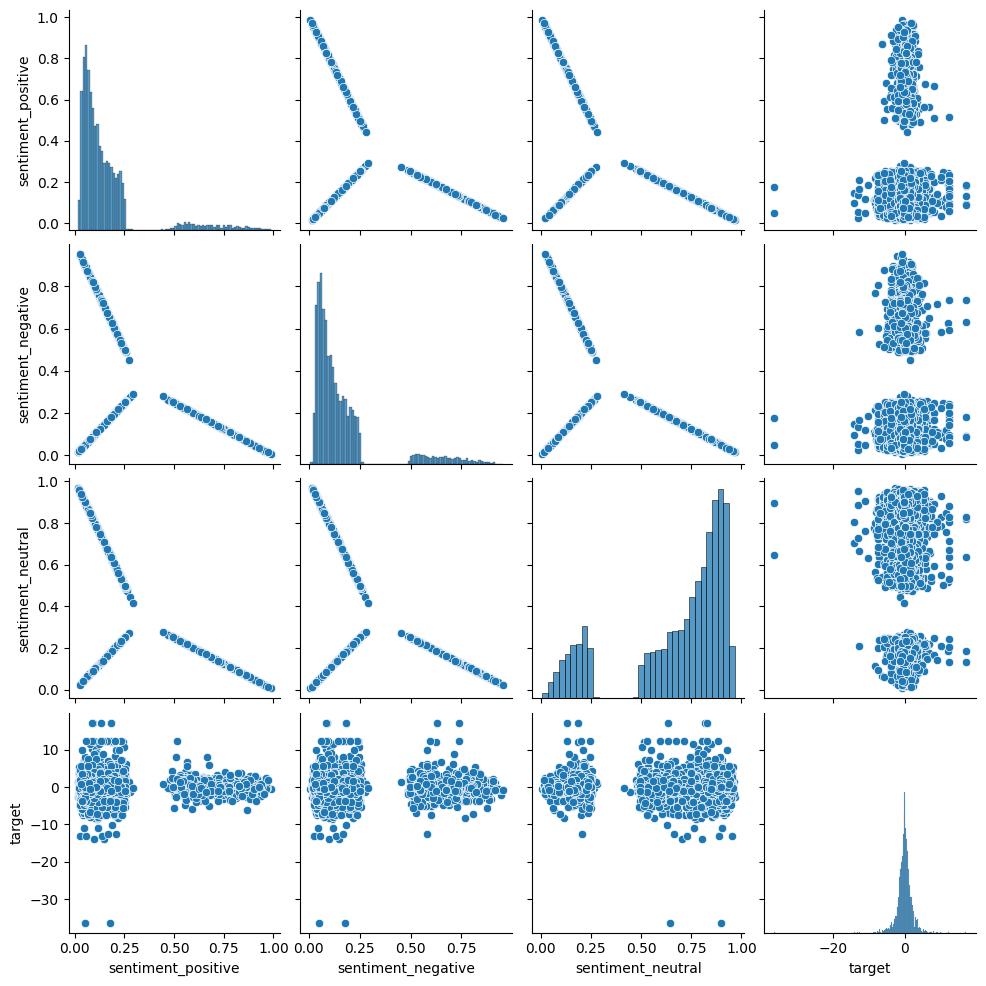

In [52]:
sns.pairplot(f[['sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'target']]);

What do we see from this graph? Positive and negative скошены вправо, most of the values around 0 of the article are mostly neutral, which is most likely due to the limitations of the neural network that analyzes the text. And histogramm neutral also confirmes it as скошено влево and most are around 0.8. Target is concentrated around 0, there are rare outliers

Positive and negative create almost a staight line. When the model says oooops it is neutral, positive and negative become the same and form a straight line. positive+neutral and negative+neutral are in contrast. if neutral is high, then +/- are low, which is quite logical since the sum always equals 1

Now let's look at the average length of the article by ticker

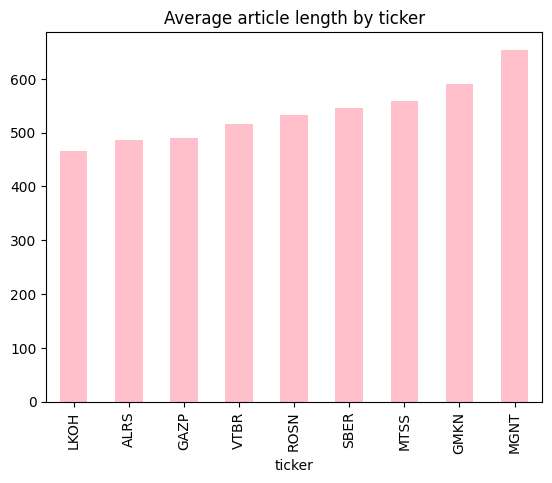

In [53]:
f['dlina'] = f['text'].str.split().str.len()
f.groupby('ticker')['dlina'].mean().sort_values().plot(kind='bar', title='Average article length by ticker', color='pink')
plt.show()

All columns are about the same length (460-660 words), the spread is small. This graph does not provide any interesting insight. Печалька и не hooray=((

Let's try it again

In [54]:
f['dlina'].describe()

,dlina
count,8249.000000
mean,536.947994
std,489.449589
min,8.000000
25%,242.000000
50%,373.000000
75%,677.000000
max,6732.000000


/tmp/ipykernel_1263/3788655404.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  f.groupby('dlinacateg')['target'].mean().plot(kind='bar', color='pink',title='The avg target for the length of the article')


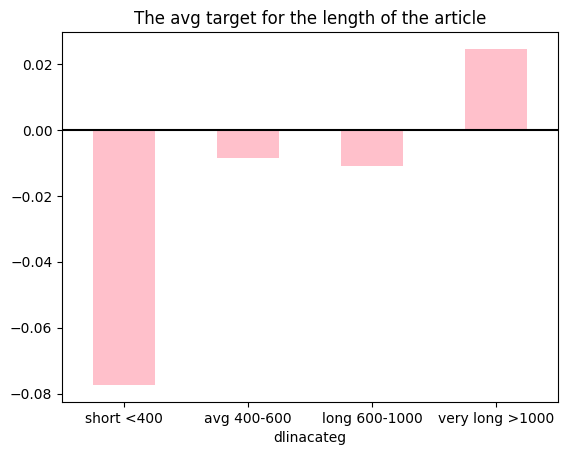

In [55]:
f['dlinacateg'] = pd.cut(f['dlina'], bins=[0, 400, 600, 1000, 10000], labels=['short <400', 'avg 400-600', 'long 600-1000', 'very long >1000'])
f.groupby('dlinacateg')['target'].mean().plot(kind='bar', color='pink',title='The avg target for the length of the article')
plt.axhline(0, color='black')
plt.xticks(rotation=0)
plt.show()

Hoooooray! A dependency was found between the length of the article and the price movement. Short news creare an average drop in price, while very long ones give a slight increase
Most likely, short articles are more often of an urgent negative nature, like it is the end of the world!!!!, everything is gone!!!, horror, disaster!!!! and long analytics are about positive materials about the company)

# We are starting to test our business hypotheses

**Н1: Negative news reduces the price more than positive news raises it**

For each article, we determine the dominant sentiment the one with the maximum value of the three.  
Then we compare the average target in each group.

In [56]:
f['glav_sentiment'] = f[['sentiment_positive', 'sentiment_negative', 'sentiment_neutral']].idxmax(axis=1)

In [57]:
f.groupby('glav_sentiment')['target'].mean()

,target
glav_sentiment,
sentiment_negative,0.026218
sentiment_neutral,-0.062874
sentiment_positive,0.092365


In [58]:
f.groupby('glav_sentiment')['target'].median()

,target
glav_sentiment,
sentiment_negative,-0.012825
sentiment_neutral,-0.023326
sentiment_positive,0.000000


In [59]:
f.groupby('glav_sentiment')['target'].std()

,target
glav_sentiment,
sentiment_negative,2.240690
sentiment_neutral,2.083043
sentiment_positive,1.653525


In [60]:
f.groupby('glav_sentiment')['target'].count()

,target
glav_sentiment,
sentiment_negative,830
sentiment_neutral,6787
sentiment_positive,632


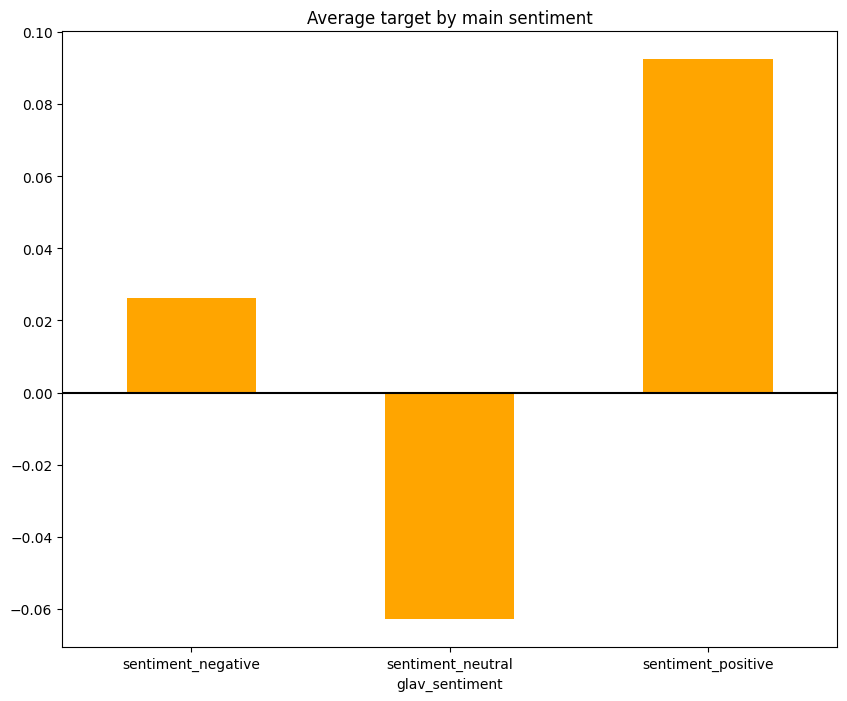

In [61]:
plt.figure(figsize=(10, 8))
f.groupby('glav_sentiment')['target'].mean().plot(kind='bar', color='orange')
plt.title('Average target by main sentiment')
plt.axhline(0, color='black')
plt.xticks(rotation=0)
plt.show()

### Conclusions on H1

The hypothesis was not confirmed........

We expected that negative news would lower the price
more than positive news would raise it, but the data showed a little (НЕ НЕМНОГО)  different:

- Positive news: average target +0.09%
- Negative news: average target +0.03% (also positive....)
- Neutral news: average target -0.06%

On average, negative news does not reduce the price (it even increases slightly).
Most likely because the sentiment alone does not determine price movement as other factors matter more: the overall market trend of the year, macroeconomic events, dividend announcements and sector news. So single article's tone gets lost in the noise of everything
else happening on the market that day.

Neutral news accounts for the biggest drop, probably because there are a lot of them and they reflect the overall weak background of the market.

Business conclusion: the tone of the news itself is not a reliable signal for a trading strategy.

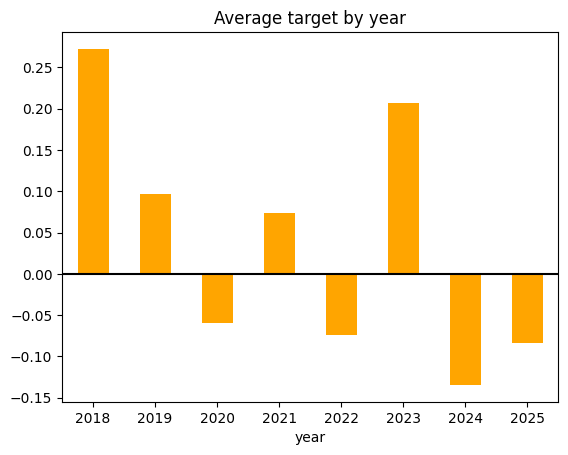

In [62]:
f['year'] = pd.to_datetime(f['published_at']).dt.year
f.groupby('year')['target'].mean().plot(kind='bar', color='orange')
plt.title('Average target by year')
plt.axhline(0, color='black')
plt.xticks(rotation=0)
plt.show()

Our team was a little confused so to better understand the results of H1, we decided to look at how the average target changed over the years. We were confused that the negative news did not lower the price - we wanted to check if any particular period was distorting the whole picture.

Since February 2022, with the collapse of the market, could strongly pull everything down and mix with neutral news.

But the graph showed something else: 2022 was not the worst year, with average target of -0.07%. The worst year was 2024 (-0.13%), the best were 2018 (+0.27%) and 2023 (+0.20%).

That is, it's not just a matter of one shock event. In 2024, the market was falling all year due to the record rate of the Central Bank of 21%, It was growing in 2023, and the tone of the news had almost no effect on it.

This further confirms the conclusion of H1: the tone of the news works only in conjunction with the macro context.
The same negative headline in the growing 2023 and in the falling year 2024, it will give a completely different target.

## **Поэтому наш анализ очень релевантен и интересен, потому что вроде бы банальные гипотезы - но они не подтверждаются..**

### H2 (improved): more ticker news - more trading volume

The initial hypothesis was that on the day the news was released, the trading volume was above average. But one news outlet may not affect anything, it's too little.

Then we restated the hypothesis: What if it's not the news itself that matters, but the amount of news about a particular ticker in one day?

We count the number of news items for each ticker for each day and see how this relates to the volume.

мы искали, как взять среднее по обьему торгов за пред 30 дней и использовали эти источники:

https://www.geeksforgeeks.org/pandas/how-to-calculate-moving-average-in-a-pandas-dataframe/
из этой статьи step 3 узнали как посчитать простое скользящее среднее по столбцам, потому что нам надо взять средний обьем торгов за 30 дней до чтобы сравнить объём сегодня со средним за последний месяц, так как если бы мы взяли просто среднее по годам, то анализ был бы не верным, потому что допустим если у сбера в 2018 году был обьем 20 млн акций в день, а в 2025 году он 50 млн, то значения в 2018 считались бы все ниже среднего, просто потому что рынок вырос, а не новости влияли на это

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rolling.html
отсюда узнали, что нам надо взять min_periods = 1, потому что без него первые 29 дней дают нули потому что окно из 30 дней ещё не заполнилось, а с этим параметром у нас например среднее для 1 дня = среднее 1 дня, по сути само значение, и далее для 2 дня = уже среднее значение вместе с 1 днем.

и нам еще нужно было понять, как считать среднее не включаяя сегодняший день и нашли вот эту статью
https://towardsdatascience.com/pandas-tricks-for-time-series-analysis-726618532172/
в статье объясняется что shift(-1) сдвигает данные вверх, то есть подтягивает следующий день к текущему. а нам нужно наоборот - сдвинуть вниз, чтобы среднее за предыдущие дни встало напротив текущего дня, поэтому берем shift(1) и считаем среднее за 30 дней и сдвигаем вниз на 1 строку

https://calmcode.io/course/pandas-datetime/rolling-groupby
тут нашли про трансформ, там написано, что The .transform() method will return an array that's as long as the grouped set going in.

поэтому без transform не получится записать результат обратно в каждую строку датафрейма одной строчкой

In [63]:
f = f.sort_values(['ticker', 'date_trading']).reset_index(drop=True)

def srednee30(obem):
    return obem.rolling(30, min_periods=1).mean().shift(1)

f['volume_srednee'] = f.groupby('ticker')['volume'].transform(srednee30)
f['volume_vishe_srednego'] = (f['volume'] > f['volume_srednee']).astype(int)
f['kolvo_novosti_po_ticker'] = f.groupby(['ticker', 'date_trading'])['title'].transform('count')
f.groupby('kolvo_novosti_po_ticker')['volume_vishe_srednego'].mean()

,volume_vishe_srednego
kolvo_novosti_po_ticker,
1,0.346844
2,0.377601
3,0.403423
4,0.442797
5,0.441481
6,0.444444
7,0.431267
8,0.422414
9,0.481481


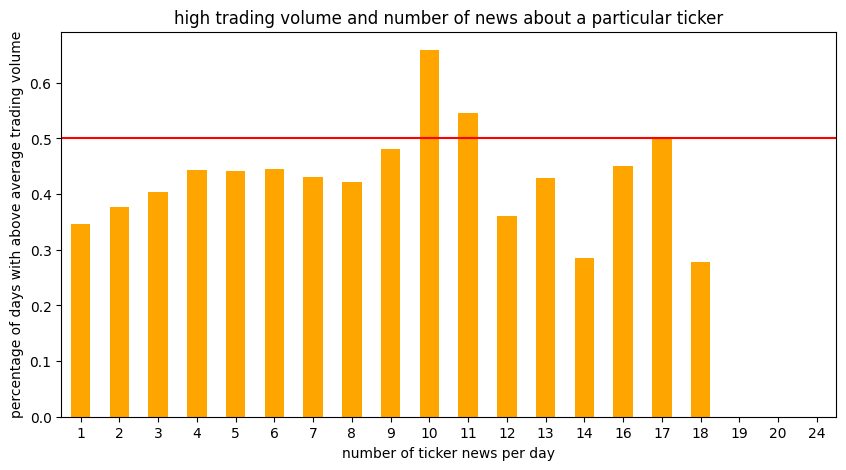

In [64]:
plt.figure(figsize=(10, 5))
f.groupby('kolvo_novosti_po_ticker')['volume_vishe_srednego'].mean().plot(kind='bar', color='orange')
plt.title('high trading volume and number of news about a particular ticker')
plt.xlabel('number of ticker news per day')
plt.ylabel('percentage of days with above average trading volume')
plt.axhline(0.5, color='red')
plt.xticks(rotation=0)
plt.show()

In [65]:
f['kolvo_novosti_po_ticker'].describe()

,kolvo_novosti_po_ticker
count,8249.000000
mean,4.293733
std,3.738923
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,24.000000


In [66]:
f['kolvo_novosti_po_ticker'].value_counts()

,count
kolvo_novosti_po_ticker,
1,1727
2,1634
3,1227
4,944
5,675
6,396
7,371
9,270
8,232


нам нужно было вывести 4 колонки с тремя разными значениями, так как в группе sentiment 3 вариации, и нашли про функцию unstack тут https://kontext.tech/project/code-snippets/article/pandas-dataframe-plot-bar-chart#bar-chart-groupby-and-unstack

/tmp/ipykernel_1263/3793680522.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  f.groupby(['news_group', 'glav_sentiment'])['volume_vishe_srednego'].mean().unstack().plot(kind='bar', figsize=(12, 8))


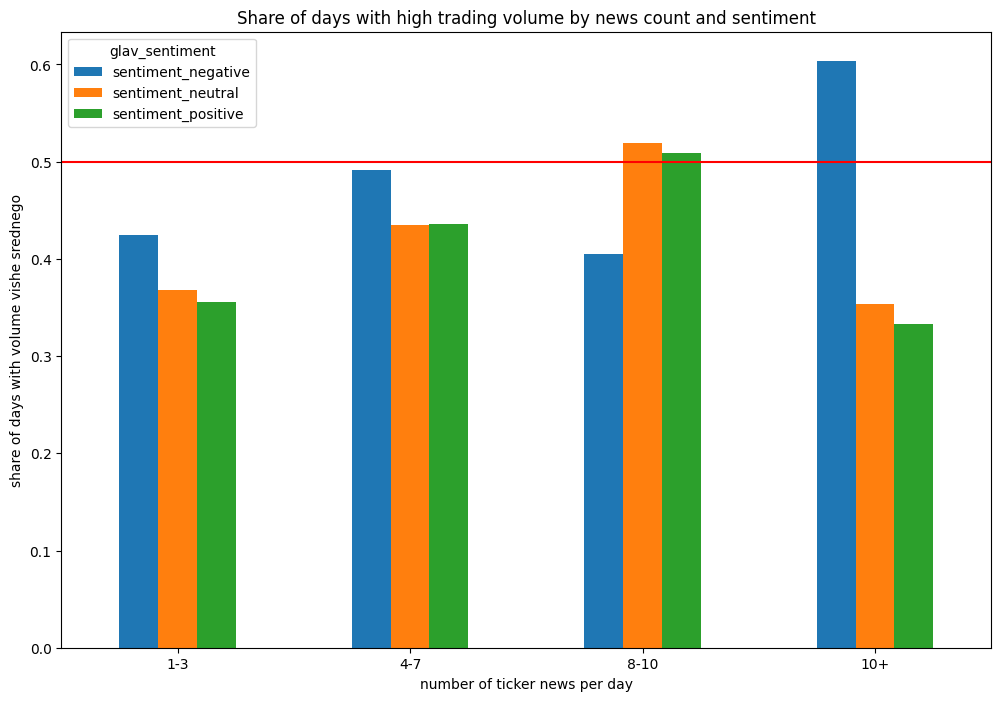

In [67]:
f['news_group'] = pd.cut(f['kolvo_novosti_po_ticker'], bins=[0, 3, 7, 10, 100], labels=['1-3', '4-7', '8-10', '10+'])
f.groupby(['news_group', 'glav_sentiment'])['volume_vishe_srednego'].mean().unstack().plot(kind='bar', figsize=(12, 8))
plt.title('Share of days with high trading volume by news count and sentiment')
plt.axhline(0.5, color='red')
plt.xlabel('number of ticker news per day')
plt.ylabel('share of days with volume vishe srednego')
plt.xticks(rotation=0)
plt.show()

### Conclusions on H2

The first chart confused us a bit - volume was growing up to 10 news items, but then suddenly dropped at 10+. We couldn't explain why more news would lead to lower trading activity. Something wasn't adding up.

So we decided to dig deeper and split the data by sentiment - maybe the type of news matters more than just the count.

And that's where it got interesting.

Negative news drives higher volume across every group.
And at 10+ negative news items about one stock in a single day, volume is above average in 60% of cases.

Meanwhile neutral and positive news at 10+ drops to around 35%.
So when there's a flood of non-negative publications - it's just noise.
The market simply doesn't react.

This explains the weird drop we saw earlier -
the 10+ group was being dragged down by neutral articles.

**The hypothesis is confirmed, but only for negative news**

**Business conclusion:** if you see a sudden spike of negative news
about a stock - expect higher volume and likely a stronger price move.

### H3: News after 18:00 has a stronger effect on the price of the next day

We get the publication hour from published_at, then divide it into two groups: before 18:00 and after, and compare the average target. The evening news comes out when the stock exchange is already closed and the market may react more sharply the next day

In [68]:
f['chas'] = pd.to_datetime(f['published_at']).dt.hour
f['chas_posle_18'] = (f['chas'] >= 18).astype(int)

In [69]:
f.groupby('chas_posle_18')['target'].mean()

,target
chas_posle_18,
0,-0.042461
1,-0.039694


In [70]:
f.groupby('chas_posle_18')['target'].median()

,target
chas_posle_18,
0,-0.028719
1,0.007302


In [71]:
f.groupby('chas_posle_18')['target'].std()

,target
chas_posle_18,
0,2.018424
1,2.322561


In [72]:
f.groupby('chas_posle_18')['target'].count()

,target
chas_posle_18,
0,6921
1,1328


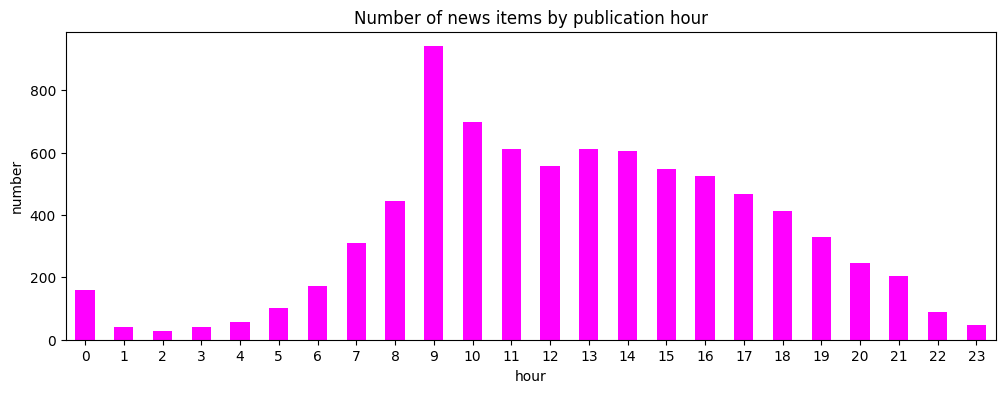

In [73]:
#the count of news after 18 is low so we decided to take a look at the distribution of news by the hour
plt.figure(figsize=(12, 4))
f['chas'].value_counts().sort_index().plot(kind='bar', color='magenta')
plt.title('Number of news items by publication hour')
plt.xlabel('hour')
plt.ylabel('number')
plt.xticks(rotation=0)
plt.show()

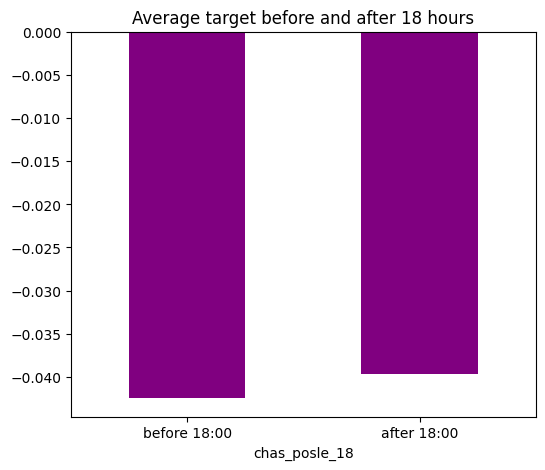

In [74]:
plt.figure(figsize=(6, 5))
f.groupby('chas_posle_18')['target'].mean().plot(kind='bar', color='purple')
plt.title('Average target before and after 18 hours')
plt.xticks([0, 1], ['before 18:00', 'after 18:00'], rotation=0)
plt.show()

### Conclusions  Н3

Ohhhh, the hypothesis was not confirmed.

The average target for news before 18:00 and after 18:00
almost identical.
The difference of tenths of a percent is too small to talk about a real impact.

At the same time, most of the RBC news comes out at peak at 9 a.m. There is much less news after 18:00,
which in itself indicates that the evening information
flow is not the main one for financial media.

Conclusion: the time of the news publication is not in itself
a significant signal for a trading strategy.
More important is the content and quantity of news about a particular promotion.